<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/ML_Chai4Boosting_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

# Part 0 : Install & Import

In [45]:
# ==========================================================
# PART 0 : Setup & Import
# ==========================================================
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Tools
import nltk
import textstat
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, log_loss, make_scorer
)

# Model Selection
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.base import clone
from scipy.sparse import hstack, csr_matrix

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler

# Config
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

# Fix Random Seed
RANDOM_STATE = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(RANDOM_STATE)
print("✅ Part 0: Setup Complete.")



✅ Part 0: Setup Complete.


# Part 1 : Feature Engineering

--- Loading Data ---
--- Generating Features ---
   Processing 100 emails...
   Processing 26 emails...

✅ [Raw] Feature Counts (Before Selection):
   - Stylometric: 52 features
   - Advanced:    8 features
   - Total:       60 features

🔍 Starting Correlation Analysis (Threshold > 0.95)...


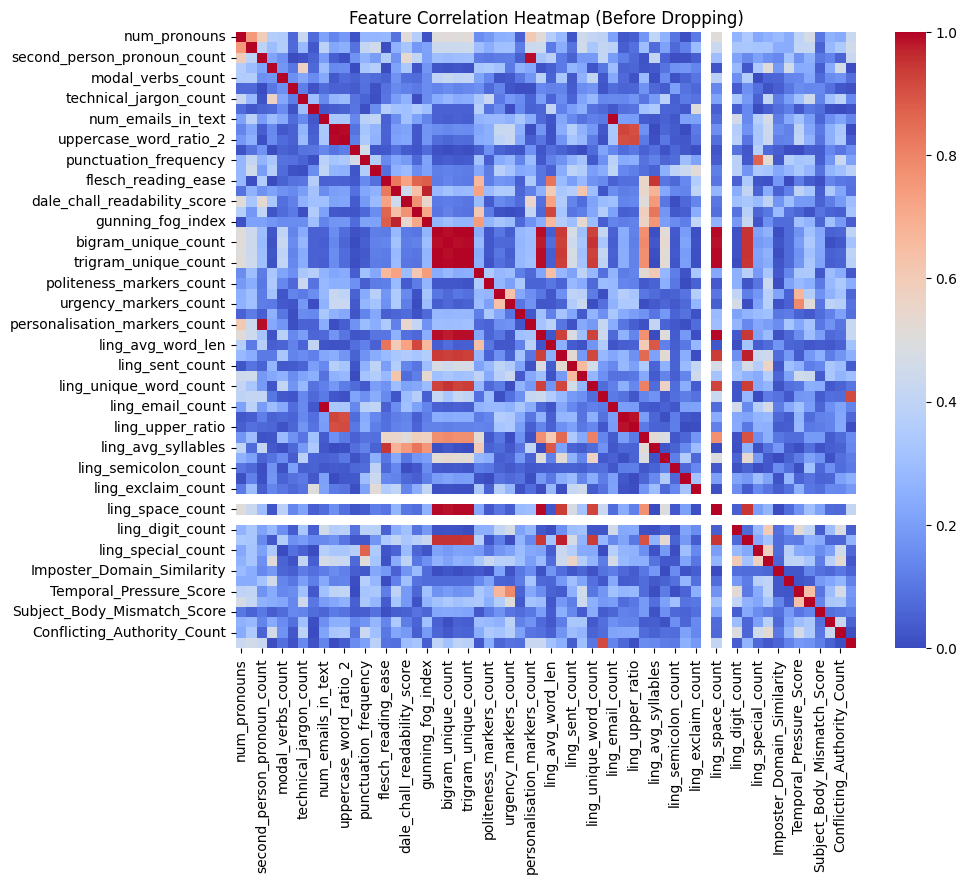

✂️ Dropping 12 features: ['uppercase_word_ratio_2', 'gunning_fog_index', 'bigram_unique_count', 'trigram_total_count', 'trigram_unique_count', 'personalisation_markers_count', 'ling_word_count', 'ling_unique_word_count', 'ling_email_count', 'ling_upper_ratio', 'ling_space_count', 'ling_alpha_count']
✅ Remaining Features: 48

✅ [Filtered] Feature Counts (After Selection):
   - Stylometric: 40
   - Advanced:    8
   - Total:       48


In [50]:
# ==========================================================
# PART 1 : Feature Engineering (Reproduce Exactly from File)
# ==========================================================
# ชื่อขั้นตอน: Feature Extraction
# หน้าที่: สกัด Features
# ไปต่อที่: -> Part 1.5 : Data preparation (Experiment setup)
# ==========================================================

VADER = SentimentIntensityAnalyzer()
WORD_RE = re.compile(r"[A-Za-z']+")
TARGET_PUNC = ['.', ',', '!', '?', ';', ':', '"', "'", '(', ')', '-', '/', '\\']

# --- Helper Functions from m_l_final (1).py ---
def tokenize_words(text: str) -> List[str]:
    text = text if isinstance(text, str) else ""
    text = re.sub(r"https?://\S+|www\.\S+", " ", text) # Strip URL
    text = re.sub(r"\S+@\S+\.\S+", " ", text) # Strip Email
    return [m.group(0).lower() for m in WORD_RE.finditer(text)]

def make_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def count_markers(tokens: List[str], vocab: List[str]) -> int:
    vocab_set = set(w.lower() for w in vocab)
    return sum(1 for t in tokens if t in vocab_set)

def count_phrase_occurrences(text: str, phrases: List[str]) -> int:
    lowered = (text or "").lower()
    return sum(len(re.findall(re.escape(p.lower()), lowered)) for p in phrases)

# --- Core Feature Extractors (Reproduce) ---

def extract_email_features(text: str) -> Dict[str, float]:
    """1. Email Specific Features (12)"""
    if not isinstance(text, str): text = ""
    words = [m.group(0).lower() for m in WORD_RE.finditer(text)]
    words_original = [m.group(0) for m in WORD_RE.finditer(text)]
    total_words = len(words) if words else 1
    uppercase_count = sum(1 for w in words_original if w.isupper() and len(w) > 1)

    return {
        "num_pronouns": sum(1 for w in words if w in ['i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them']),
        "first_person_pronoun_count": sum(1 for w in words if w in ['i', 'we', 'me', 'us', 'my', 'our', 'mine', 'ours']),
        "second_person_pronoun_count": sum(1 for w in words if w in ['you', 'your', 'yours']),
        "imperative_verbs_count": sum(1 for w in words if w in ['click', 'verify', 'submit', 'download', 'update', 'open', 'enable', 'call', 'contact']),
        "modal_verbs_count": sum(1 for w in words if w in ['can', 'could', 'should', 'would', 'must', 'may', 'might']),
        "uncertainty_adverbs_count": sum(1 for w in words if w in ['maybe', 'possibly', 'perhaps', 'probably', 'likely']),
        "technical_jargon_count": sum(1 for w in words if w in ['security', 'account', 'update', 'technical', 'password', 'login', 'verify', 'authentication']),
        "promotional_words_count": sum(1 for w in words if w in ['offer', 'deal', 'free', 'discount', 'promotion', 'bonus', 'limited', 'exclusive']),
        "num_emails_in_text": len(re.findall(r'@', text)),
        "uppercase_word_count_2": uppercase_count,
        "uppercase_word_ratio_2": uppercase_count / total_words,
        "attachment_words_count": sum(1 for w in words if w in ['attachment']),
    }

def punctuation_features(text: str) -> Dict[str, float]:
    """2. Punctuation Features (2)"""
    s = str(text) if text else ""
    if len(s) == 0: return {"punctuation_frequency": 0.0, "punctuation_variety": 0.0}

    count = sum(s.count(p) for p in TARGET_PUNC)
    variety = sum(1 for p in TARGET_PUNC if p in s)
    return {"punctuation_frequency": count / len(s), "punctuation_variety": float(variety)}

def readability_features(text: str) -> Dict[str, float]:
    """3. Readability Features (5)"""
    s = str(text) if text else ""
    try:
        return {
            "flesch_reading_ease": textstat.flesch_reading_ease(s),
            "smog_index": textstat.smog_index(s),
            "dale_chall_readability_score": textstat.dale_chall_readability_score(s),
            "coleman_liau_index": textstat.coleman_liau_index(s),
            "gunning_fog_index": textstat.gunning_fog(s)
        }
    except:
        return {k: 0.0 for k in ["flesch_reading_ease", "smog_index", "dale_chall_readability_score", "coleman_liau_index", "gunning_fog_index"]}

def extract_stylo_features(text: str) -> Dict[str, float]:
    """4. Stylometric N-grams & Markers (10)"""
    tokens = tokenize_words(text)
    bigrams = make_ngrams(tokens, 2)
    trigrams = make_ngrams(tokens, 3)
    word_lens = [len(w) for w in tokens] or [0]

    try:
        from statistics import pstdev
        std_var = pstdev(word_lens)
    except:
        std_var = 0.0

    return {
        "bigram_total_count": float(len(bigrams)),
        "bigram_unique_count": float(len(set(bigrams))),
        "trigram_total_count": float(len(trigrams)),
        "trigram_unique_count": float(len(set(trigrams))),
        "word_length_variation_std": float(std_var),
        "politeness_markers_count": count_markers(tokens, ['please', 'thank', 'appreciate', 'thanks', 'kindly']),
        "aggressiveness_markers_count": count_markers(tokens, ['must', 'now', 'immediately', 'demand', 'require']),
        "urgency_markers_count": count_markers(tokens, ['urgent', 'asap', 'immediately', 'soon']),
        "conditional_phrases_count": count_markers(tokens, ['if', 'unless', 'provided', 'should', 'whenever']),
        "personalisation_markers_count": count_markers(tokens, ["you", "your"]) + count_phrase_occurrences(text, ['[recipient', '[your name]']),
    }

def analyze_email_body(text: str) -> Dict[str, float]:
    """5. Linguistic Features (23) - from analyze_email_body"""
    if not text: return {f'ling_{i}': 0.0 for i in range(23)}

    words = word_tokenize(text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(text)

    word_count = len(lower_words)
    sent_count = len(sentences)
    if word_count == 0: return {f'ling_{i}': 0.0 for i in range(23)}

    # Calculations based on m_l_final logic
    avg_word_len = sum(len(w) for w in lower_words) / word_count
    char_count = len(text)
    avg_sent_len = word_count / sent_count if sent_count > 0 else 0
    unique_count = len(set(lower_words))
    lexical_div = unique_count / word_count
    email_count = text.count('@')
    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / word_count
    complex_count = sum(1 for w in lower_words if len(w) > 6)

    try:
        avg_syllables = sum(textstat.syllable_count(w) for w in lower_words) / word_count
    except:
        avg_syllables = 0

    # Create the 23 specific features dictionary
    # Note: Mapping index to name based on standard linguistic sets or generic names
    # Since the original returns tuple, I will map to generic names to match count
    feats = {
        "ling_word_count": float(word_count),
        "ling_avg_word_len": avg_word_len,
        "ling_char_count": float(char_count),
        "ling_sent_count": float(sent_count),
        "ling_avg_sent_len": avg_sent_len,
        "ling_unique_word_count": float(unique_count),
        "ling_lexical_diversity": lexical_div,
        "ling_email_count": float(email_count),
        "ling_upper_count": float(upper_count),
        "ling_upper_ratio": upper_ratio,
        "ling_complex_count": float(complex_count),
        "ling_avg_syllables": avg_syllables,
        "ling_comma_count": float(text.count(',')),
        "ling_semicolon_count": float(text.count(';')),
        "ling_quote_count": float(text.count('"') + text.count("'")),
        "ling_exclaim_count": float(text.count('!')),
        "ling_question_count": float(text.count('?')),
        "ling_space_count": float(text.count(' ')),
        "ling_tab_count": float(text.count('\t')),
        "ling_digit_count": float(sum(c.isdigit() for c in text)),
        "ling_alpha_count": float(sum(c.isalpha() for c in text)),
        "ling_special_count": float(len(re.findall(r'[^a-zA-Z0-9\s]', text))),
        "ling_line_count": float(len(text.splitlines()))
    }
    return feats

def get_paper_stylometric_features(text: str) -> Dict[str, float]:
    """
    Combine all reproduce features:
    Email(12) + Punct(2) + Readability(5) + Stylo(10) + Ling(23) = ~52 Features
    """
    feats = {}
    feats.update(extract_email_features(text))
    feats.update(punctuation_features(text))
    feats.update(readability_features(text))
    feats.update(extract_stylo_features(text))
    feats.update(analyze_email_body(text))
    return feats

# --- Advanced Features (New Idea) - Keep Original Logic ---
def get_advanced_features(row):
    text = str(row['Subject']) + " " + str(row['Body'])
    lower_text = text.lower()

    url_match = re.search(r"https?://(?:www\.)?([^/]+)", text)
    domain = url_match.group(1) if url_match else ""
    imposter_sim = difflib.SequenceMatcher(None, "security", domain).ratio() if domain else 0.0

    macro_kw = ["enable macro", "enable content", "security alert", "yellow bar"]
    macro_count = sum(1 for kw in macro_kw if kw in lower_text)

    pressure_kw = ["urgent", "immediately", "asap", "24 hours", "suspend", "expire", "deadline"]
    pressure_score = sum(1 for kw in pressure_kw if kw in lower_text)

    action_kw = ["click", "verify", "login", "update", "confirm"]
    coercion_dens = 0.0
    if pressure_score > 0:
        coercion_dens = sum(1 for k in action_kw if k in lower_text) / (len(lower_text.split()) + 1)

    sub_tok = set(str(row['Subject']).lower().split())
    body_tok = set(str(row['Body']).lower().split())
    mismatch = 1.0 - (len(sub_tok.intersection(body_tok)) / len(sub_tok.union(body_tok))) if len(sub_tok.union(body_tok)) > 0 else 1.0

    sents = sent_tokenize(text)
    pols = [VADER.polarity_scores(s)['compound'] for s in sents]
    pol_var = np.std(pols) if len(pols) > 1 else 0.0

    auth_kw = ["support", "admin", "security team", "bank"]
    violation_kw = ["click here", "password", "download", "attachment"]
    conflict = sum(1 for a in auth_kw for v in violation_kw if a in lower_text and v in lower_text)

    words = lower_text.split()
    cohesion = len(set(words)) / len(words) if len(words) > 0 else 0.0

    return {
        "Imposter_Domain_Similarity": imposter_sim,
        "Macro_Security_Bypass_Count": macro_count,
        "Temporal_Pressure_Score": pressure_score,
        "Action_Time_Coercion_Density": coercion_dens,
        "Subject_Body_Mismatch_Score": mismatch,
        "Emotional_Polarity_Variance": pol_var,
        "Conflicting_Authority_Count": conflict,
        "Semantic_Cohesion_Score": cohesion
    }

def process_features(df):
    rows = []
    print(f"   Processing {len(df)} emails...")
    for _, row in df.iterrows():
        text = str(row['Subject']) + " " + str(row['Body'])
        stylo = get_paper_stylometric_features(text)
        adv = get_advanced_features(row)
        rows.append({**stylo, **adv})
    return pd.DataFrame(rows)

print("--- Loading Data ---")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
for df in [train_df, test_df]:
    df['Subject'] = df['Subject'].fillna("")
    df['Body'] = df['Body'].fillna("")

print("--- Generating Features ---")
# สร้าง Features ทั้งหมดก่อน (ยังไม่ตัด)
X_train_meta = process_features(train_df)
X_test_meta = process_features(test_df)
y_train = train_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values
y_test = test_df['Label'].map({'Phishing': 1, 'Legitimate': 0}).values

# เก็บรายชื่อคอลัมน์ดิบไว้ใช้สำหรับ Reproduce (Untuned)
ALL_COLS = list(X_train_meta.columns)
ADV_COLS_RAW = list(get_advanced_features(train_df.iloc[0]).keys())
STYLO_COLS_RAW = [c for c in ALL_COLS if c not in ADV_COLS_RAW]

print(f"\n✅ [Raw] Feature Counts (Before Selection):")
print(f"   - Stylometric: {len(STYLO_COLS_RAW)} features")
print(f"   - Advanced:    {len(ADV_COLS_RAW)} features")
print(f"   - Total:       {len(ALL_COLS)} features")

# ==========================================================
# PART 1.2 : Feature Selection (For Tuned Experiments)
# ==========================================================
def analyze_and_remove_correlations(df, threshold=0.95):
    print(f"\n🔍 Starting Correlation Analysis (Threshold > {threshold})...")
    corr_matrix = df.corr().abs()

    # Plot Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
    plt.title("Feature Correlation Heatmap (Before Dropping)")
    plt.show()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    df_dropped = df.drop(columns=to_drop)
    print(f"✂️ Dropping {len(to_drop)} features: {to_drop}")
    print(f"✅ Remaining Features: {df_dropped.shape[1]}")
    return df_dropped, to_drop

# สร้างชุดข้อมูลที่ "คัดกรองแล้ว" สำหรับ New Ideas
X_train_meta_filtered, dropped_cols = analyze_and_remove_correlations(X_train_meta, threshold=0.95)
X_test_meta_filtered = X_test_meta.drop(columns=dropped_cols)

# Update Column Lists (Filtered)
ADV_COLS_FILTERED = [c for c in ADV_COLS_RAW if c not in dropped_cols]
STYLO_COLS_FILTERED = [c for c in X_train_meta_filtered.columns if c not in ADV_COLS_FILTERED]

print(f"\n✅ [Filtered] Feature Counts (After Selection):")
print(f"   - Stylometric: {len(STYLO_COLS_FILTERED)}")
print(f"   - Advanced:    {len(ADV_COLS_FILTERED)}")
print(f"   - Total:       {X_train_meta_filtered.shape[1]}")


# Part 1.5 : Data Preparation (Experiments Setup)



In [54]:
# ==========================================================
# PART 1.5 : Data Preparation (Experiments Setup)
# ==========================================================
# ขั้นตอน: Data Splitting & TF-IDF
# คำอธิบาย: เตรียม Dataset สำหรับ 5 Experiments
# ไปต่อที่: -> Part 2 : Models & Tuning
# ==========================================================

print("\n--- Generating TF-IDF Features (Max=300) ---")
tfidf = TfidfVectorizer(max_features=300,
                        stop_words='english',
                        ngram_range=(1, 2) )

X_train_tfidf = tfidf.fit_transform(train_df['Subject'] + " " + train_df['Body']).toarray()
X_test_tfidf = tfidf.transform(test_df['Subject'] + " " + test_df['Body']).toarray()
tfidf_names = list(tfidf.get_feature_names_out())

# Models subset for Paper Reproduction
PAPER_MODELS = ["LogisticRegression", "SVM", "RandomForest", "XGBoost"]

experiments = {
    # 1. Reproduced (Untuned): 4 Models, No Tuning, No Feature Selection (Raw Stylo)
    "Reproduce_Untuned": {
        "type": "Reproduce (Baseline) 📜",
        "detail": "Stylometric Features Only | 4 Paper Models | No Tuning | No Feat. Selection",
        "X_train": X_train_meta[STYLO_COLS_RAW].values,  # ใช้ตัวดิบ
        "X_test": X_test_meta[STYLO_COLS_RAW].values,    # ใช้ตัวดิบ
        "feat_names": STYLO_COLS_RAW,
        "models_to_run": PAPER_MODELS,
        "do_tuning": False
    },

    # 2. Reproduced (Tuned): 9 Models, Tuned, Feature Selection
    "Reproduce_Tuned": {
        "type": "Reproduce (Optimized) 🚀",
        "detail": "Stylometric Features Only | All 9 Models | With Tuning & Selection",
        "X_train": X_train_meta_filtered[STYLO_COLS_FILTERED].values,
        "X_test": X_test_meta_filtered[STYLO_COLS_FILTERED].values,
        "feat_names": STYLO_COLS_FILTERED,
        "models_to_run": "all",
        "do_tuning": True
    },

    # 3. Exp A (New Idea): Stylo + Adv (Tuned)
    "Exp_A": {
        "type": "New Idea (Behavioral) 💡",
        "detail": "Stylo + Advanced Features | With Tuning & Selection",
        "X_train": X_train_meta_filtered.values,
        "X_test": X_test_meta_filtered.values,
        "feat_names": list(X_train_meta_filtered.columns),
        "models_to_run": "all",
        "do_tuning": True
    },

    # 4. Exp B (New Idea): TF-IDF Only
    "Exp_B": {
        "type": "New Idea (Content) 📝",
        "detail": "TF-IDF Only | With Tuning",
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feat_names": tfidf_names,
        "models_to_run": "all",
        "do_tuning": True
    },

    # 5. Exp C (New Idea): Combined
    "Exp_C": {
        "type": "New Idea (Hybrid) 🧬",
        "detail": "Combined All Features | With Tuning",
        "X_train": hstack([X_train_tfidf, csr_matrix(X_train_meta_filtered.values)]).toarray(),
        "X_test": hstack([X_test_tfidf, csr_matrix(X_test_meta_filtered.values)]).toarray(),
        "feat_names": tfidf_names + list(X_train_meta_filtered.columns),
        "models_to_run": "all",
        "do_tuning": True
    }
}

# แสดงจำนวน Features ของแต่ละการทดลอง เพื่อตรวจสอบความถูกต้อง
for name, data in experiments.items():
    print(f"   [{name}] Features Count: {data['X_train'].shape[1]}")



--- Generating TF-IDF Features (Max=300) ---
   [Reproduce_Untuned] Features Count: 52
   [Reproduce_Tuned] Features Count: 40
   [Exp_A] Features Count: 48
   [Exp_B] Features Count: 300
   [Exp_C] Features Count: 348


# Part 2 : Models + Optuna Tuning (K=5)

In [60]:
# ==========================================================
# PART 2 : Models & Optuna Tuning
# ==========================================================
# ขั้นตอน: Model Configuration
# คำอธิบาย: กำหนด 9 Models (รวม DecisionTree)
# ไปต่อที่: -> Part 3 : Running Experiments
# ==========================================================

# รายชื่อโมเดลทั้ง 9 ตัวที่ใช้ในการทดลอง
MODELS_MAP = {
    "LogisticRegression": LogisticRegression, "SVM": SVC, "RandomForest": RandomForestClassifier,
    "XGBoost": XGBClassifier, "AdaBoost": AdaBoostClassifier, "CatBoost": CatBoostClassifier,
    "LightGBM": LGBMClassifier, "NaiveBayes": MultinomialNB, "DecisionTree": DecisionTreeClassifier
}

def get_default_model(model_name):
    """Return model with default parameters (Fixed Random State)"""
    if model_name == "LogisticRegression":
      return LogisticRegression(random_state=RANDOM_STATE)
    if model_name == "SVM":
      return SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
    if model_name == "RandomForest":
      return RandomForestClassifier(random_state=RANDOM_STATE)
    if model_name == "XGBoost":
      return XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
    return None

def get_optuna_model(trial, model_name):
    """Return model with Optuna parameters"""
    if model_name == "LogisticRegression":
      return LogisticRegression(
          C=trial.suggest_float("C", 1e-3, 100, log=True),
          solver='liblinear',
          random_state=RANDOM_STATE)
    if model_name == "SVM":
      return SVC(
          C=trial.suggest_float("C", 1e-3, 100, log=True),
          kernel="linear",
          probability=True,
          random_state=RANDOM_STATE)
    if model_name == "RandomForest":
      return RandomForestClassifier(
          n_estimators=trial.suggest_int("n_est", 50, 300),
          max_depth=trial.suggest_int("depth", 3, 20),
          random_state=RANDOM_STATE)
    if model_name == "XGBoost":
      return XGBClassifier(
          n_estimators=trial.suggest_int("n_est", 50, 300),
          learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
          max_depth=trial.suggest_int("depth", 3, 10),
          use_label_encoder=False,
          eval_metric='logloss',
          random_state=RANDOM_STATE)
    if model_name == "AdaBoost":
      return AdaBoostClassifier(
          n_estimators=trial.suggest_int("n_est", 30, 200),
          learning_rate=trial.suggest_float("lr", 0.01, 1.0, log=True),
          random_state=RANDOM_STATE)
    if model_name == "CatBoost":
      return CatBoostClassifier(iterations=trial.suggest_int("itr", 50, 300),
                                depth=trial.suggest_int("depth", 4, 10),
                                learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True), verbose=0, random_state=RANDOM_STATE)
    if model_name == "LightGBM":
      return LGBMClassifier(n_estimators=trial.suggest_int("n_est", 50, 300),
                            learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
                            num_leaves=trial.suggest_int("num_leaves", 20, 100),
                            verbose=-1,
                            random_state=RANDOM_STATE)
    if model_name == "NaiveBayes":
      return MultinomialNB(alpha=trial.suggest_float("alpha", 0.01, 10.0,
                                                     log=True))
    if model_name == "DecisionTree":
      return DecisionTreeClassifier(max_depth=trial.suggest_int("max_depth", 3, 30),
                                    min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
                                    criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
                                    random_state=RANDOM_STATE)


# Part 3 – Running Experiments & Evaluation Loop

In [72]:
# ==========================================================
# PART 3 : Running Experiments & Helpers
# ==========================================================
# ขั้นตอน: Experiments Loop
# คำอธิบาย: Run -> Tune -> Train -> Test -> Plot
# ไปต่อที่: -> Part 4 : Main Flow
# ==========================================================

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred), "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0), "F1-score": f1_score(y_true, y_pred),
        "MCC-score": matthews_corrcoef(y_true, y_pred), "AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else 0,
        "PR": average_precision_score(y_true, y_prob) if y_prob is not None else 0
    }

def plot_feature_importance(model, feat_names, model_name, exp_name):
    imp = None
    if hasattr(model, "feature_importances_"): imp = model.feature_importances_
    elif hasattr(model, "coef_"): imp = np.abs(model.coef_[0]) if model.coef_.ndim > 1 else np.abs(model.coef_)
    elif hasattr(model, "feature_log_prob_"): imp = np.std(model.feature_log_prob_, axis=0)

    if imp is not None:
        if len(imp) != len(feat_names): return

        # 1. Sort Features
        feat_imp = pd.Series(imp, index=feat_names).sort_values(ascending=False)

        # 2. Split Top 10 & Others
        top_10 = feat_imp.head(10)
        others_sum = feat_imp.iloc[10:].sum() if len(feat_imp) > 10 else 0

        # 3. Prepare Data for Plotting (Others at bottom, then Top 10 -> Top 1)
        if others_sum > 0:
            plot_indices = ['Others'] + list(top_10.index[::-1])
            plot_values = [others_sum] + list(top_10.values[::-1])
        else:
            plot_indices = list(top_10.index[::-1])
            plot_values = list(top_10.values[::-1])

        # 4. Plot
        plt.figure(figsize=(10, 6))
        bars = plt.barh(plot_indices, plot_values, color='teal')

        # Change 'Others' bar color to gray if it exists
        if others_sum > 0:
            bars[0].set_color('gray')

        plt.title(f"Top 10 Features + Others - {model_name} ({exp_name})")
        plt.xlabel("Importance Score")

        # 5. Add Data Labels (%)
        total_imp = imp.sum()
        total_imp = 1 if total_imp == 0 else total_imp

        for bar in bars:
            width = bar.get_width()
            pct = (width / total_imp) * 100
            plt.text(width, bar.get_y() + bar.get_height()/2,
                     f' {width:.4f} ({pct:.1f}%)',
                     va='center', fontsize=9, color='black')

        plt.tight_layout()
        plt.show()

def plot_cost_function(model, X_train, y_train, X_test, y_test, model_name):
    plt.figure(figsize=(8, 5)); train_loss, test_loss, x_axis = [], [], []
    print(f"\n📈 Generating Cost Function Chart for {model_name}...")

    if model_name in ["XGBoost", "LightGBM", "CatBoost"]:
        model_c = clone(model)
        eval_set = [(X_train, y_train), (X_test, y_test)]
        if model_name == "XGBoost": model_c.fit(X_train, y_train, eval_set=eval_set, verbose=False); res = model_c.evals_result(); train_loss = res['validation_0']['logloss']; test_loss = res['validation_1']['logloss']
        elif model_name == "LightGBM": model_c.fit(X_train, y_train, eval_set=eval_set, eval_metric="binary_logloss"); res = model_c.evals_result_; train_loss = res['training']['binary_logloss']; test_loss = res['valid_1']['binary_logloss']
        elif model_name == "CatBoost": model_c.fit(X_train, y_train, eval_set=eval_set, verbose=False); res = model_c.get_evals_result(); train_loss = res['learn']['Logloss']; test_loss = res['validation']['Logloss']
        x_axis = range(1, len(train_loss) + 1); plt.xlabel("Iterations")
    else:
        cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        train_sizes, train_scores, test_scores = learning_curve(
            model, X_train, y_train, cv=cv_lc, scoring='neg_log_loss',
            train_sizes=np.linspace(0.1, 1.0, 5), random_state=RANDOM_STATE
        )
        train_loss = -np.mean(train_scores, axis=1); test_loss = -np.mean(test_scores, axis=1); x_axis = train_sizes; plt.xlabel("Training Set Size")

    if len(train_loss) > 0:
        plt.plot(x_axis, train_loss, 'r.-', label='Train Loss'); plt.plot(x_axis, test_loss, 'b.-', label='Validation Loss')
        plt.title(f"Overfitting Check - {model_name}"); plt.ylabel("Log Loss"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

def run_experiment(exp_name, data):
    exp_type = data.get("type", "Experiment")
    exp_detail = data.get("detail", "-")
    do_tuning = data.get("do_tuning", True)
    models_to_run = data.get("models_to_run", "all")

    print(f"\n\n{'='*60}\n🧬 EXPERIMENT: {exp_name}\n📌 Type: {exp_type}\n📝 Detail: {exp_detail}\n{'='*60}\n")

    X_tr, X_te = data['X_train'], data['X_test']
    if "NaiveBayes" in MODELS_MAP and np.min(X_tr) < 0: min_v = np.min(X_tr); X_tr -= min_v; X_te -= min_v

    target_models = MODELS_MAP.keys() if models_to_run == "all" else models_to_run

    res_train, res_val, res_test, models, best_params_dict, res_cm = [], [], [], {}, {}, []
    cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    cv_valid = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for idx, name in enumerate(target_models, 1):
        status = "Tuning..." if do_tuning else "Running (Default)..."
        print(f"[{idx}/{len(target_models)}] {status} {name}")

        if do_tuning:
            sampler = TPESampler(seed=RANDOM_STATE)
            study = optuna.create_study(direction="maximize", sampler=sampler)
            study.optimize(
                lambda t: cross_val_score(
                    get_optuna_model(t, name),
                    X_tr,
                    y_train,
                    cv=cv_tuning,
                    scoring='f1').mean(), n_trials=20)
            best_m = get_optuna_model(study.best_trial, name)
            best_params_dict[name] = study.best_params
            print(f"   ✅ Best Params: {study.best_params}")
        else:
            best_m = get_default_model(name)
            best_params_dict[name] = "Default"

        scoring_cv = {'f1': 'f1', 'mcc': make_scorer(matthews_corrcoef), 'acc': 'accuracy', 'auc': 'roc_auc', 'prec': 'precision', 'rec': 'recall'}
        cv_res = cross_validate(best_m, X_tr, y_train, cv=cv_valid, scoring=scoring_cv)
        res_val.append({
            "Model": name, "F1-score": cv_res['test_f1'].mean(), "MCC-score": cv_res['test_mcc'].mean(),
            "Accuracy": cv_res['test_acc'].mean(), "AUC": cv_res['test_auc'].mean(),
            "Precision": cv_res['test_prec'].mean(), "Recall": cv_res['test_rec'].mean()
        })

        best_m.fit(X_tr, y_train)
        y_p_tr = best_m.predict(X_tr)
        y_pb_tr = best_m.predict_proba(X_tr)[:, 1] if hasattr(best_m, "predict_proba") else best_m.decision_function(X_tr)
        res_train.append({"Model": name, **calculate_metrics(y_train, y_p_tr, y_pb_tr)})

        y_p_te = best_m.predict(X_te)
        y_pb_te = best_m.predict_proba(X_te)[:, 1] if hasattr(best_m, "predict_proba") else best_m.decision_function(X_te)
        res_test.append({"Model": name, **calculate_metrics(y_test, y_p_te, y_pb_te)})

        # CM
        tn, fp, fn, tp = confusion_matrix(y_test, y_p_te).ravel()
        res_cm.append({"Model": name, "TN": tn, "FP": fp, "FN": fn, "TP": tp})

        models[name] = best_m

    df_tr = pd.DataFrame(res_train).sort_values("F1-score", ascending=False).set_index("Model")
    df_val = pd.DataFrame(res_val).sort_values("F1-score", ascending=False).set_index("Model")
    df_te = pd.DataFrame(res_test).sort_values("F1-score", ascending=False).set_index("Model")
    df_cm = pd.DataFrame(res_cm).set_index("Model")

    print(f"\n📊 {exp_name} - Training Set"); display(df_tr)
    print(f"\n📊 {exp_name} - Validation Set (CV Mean)"); display(df_val)
    print(f"\n📊 {exp_name} - Test Set (Unseen Data)"); display(df_te)
    print(f"\n📊 {exp_name} - Confusion Matrix (Test Set)"); display(df_cm)

    best_model_name = df_te.index[0]
    print(f"⭐ Best Model: {best_model_name}")
    plot_feature_importance(models[best_model_name], data['feat_names'], best_model_name, exp_name)

    return df_te, models, data, best_params_dict


# Part 4 – Main Flow
- Evaluation & Confusion Matrix
- ROC/PR Curves
- Top 10 Features



🧬 EXPERIMENT: Reproduce_Untuned
📌 Type: Reproduce (Baseline) 📜
📝 Detail: Stylometric Features Only | 4 Paper Models | No Tuning | No Feat. Selection

[1/4] Running (Default)... LogisticRegression
[2/4] Running (Default)... SVM
[3/4] Running (Default)... RandomForest
[4/4] Running (Default)... XGBoost

📊 Reproduce_Untuned - Training Set


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LogisticRegression,0.9900,1.0000,0.9804,0.9901,0.9802,0.9976,0.9975



📊 Reproduce_Untuned - Validation Set (CV Mean)


,F1-score,MCC-score,Accuracy,AUC,Precision,Recall
Model,,,,,,
RandomForest,0.8860,0.7699,0.8800,0.9500,0.8616,0.9200
XGBoost,0.8594,0.7450,0.8700,0.9700,0.8868,0.8400
SVM,0.8587,0.7247,0.8600,0.9360,0.8622,0.8600
LogisticRegression,0.8401,0.6908,0.8400,0.9420,0.8516,0.8400



📊 Reproduce_Untuned - Test Set (Unseen Data)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,0.8462,0.7692,0.9091,0.8333,0.7006,0.9290,0.9279
SVM,0.8077,0.7692,0.8333,0.8000,0.6172,0.8994,0.8779
LogisticRegression,0.7692,0.6923,0.8182,0.7500,0.5449,0.8994,0.8749
XGBoost,0.7692,0.6923,0.8182,0.7500,0.5449,0.9349,0.9430



📊 Reproduce_Untuned - Confusion Matrix (Test Set)


,TN,FP,FN,TP
Model,,,,
LogisticRegression,11,2,4,9
SVM,11,2,3,10
RandomForest,12,1,3,10
XGBoost,11,2,4,9


⭐ Best Model: RandomForest


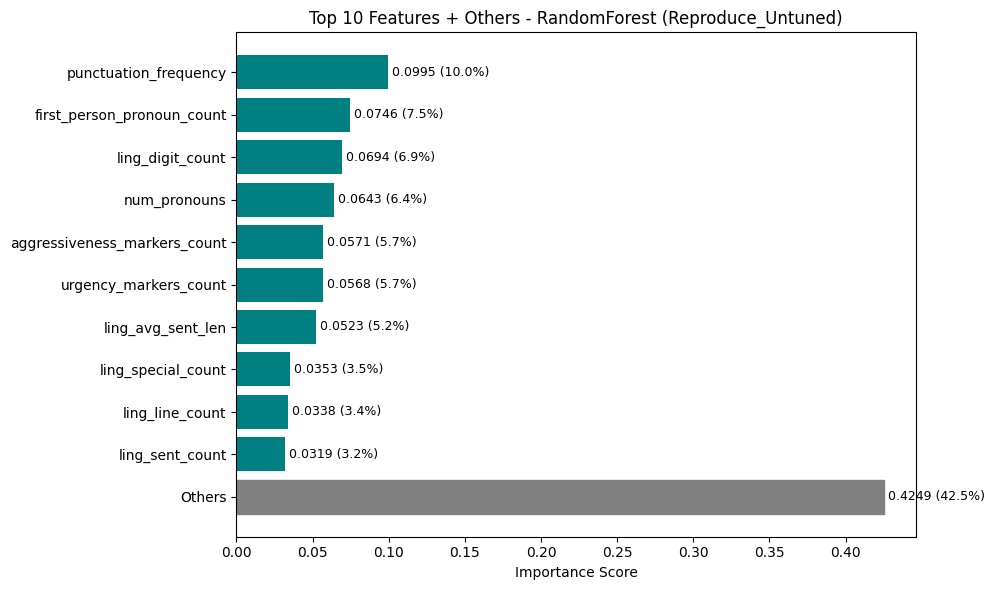



🧬 EXPERIMENT: Reproduce_Tuned
📌 Type: Reproduce (Optimized) 🚀
📝 Detail: Stylometric Features Only | All 9 Models | With Tuning & Selection

[1/9] Tuning... LogisticRegression
   ✅ Best Params: {'C': 0.0745934328572655}
[2/9] Tuning... SVM
   ✅ Best Params: {'C': 0.0010215156685612666}
[3/9] Tuning... RandomForest
   ✅ Best Params: {'n_est': 55, 'depth': 20}
[4/9] Tuning... XGBoost
   ✅ Best Params: {'n_est': 137, 'lr': 0.20481324185550148, 'depth': 5}
[5/9] Tuning... AdaBoost
   ✅ Best Params: {'n_est': 155, 'lr': 0.15751320499779725}
[6/9] Tuning... CatBoost
   ✅ Best Params: {'itr': 164, 'depth': 9, 'lr': 0.019721610970574007}
[7/9] Tuning... LightGBM
   ✅ Best Params: {'n_est': 258, 'lr': 0.020589728197687916, 'num_leaves': 34}
[8/9] Tuning... NaiveBayes
   ✅ Best Params: {'alpha': 0.13292918943162169}
[9/9] Tuning... DecisionTree
   ✅ Best Params: {'max_depth': 24, 'min_samples_split': 6, 'criterion': 'gini'}

📊 Reproduce_Tuned - Training Set


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LogisticRegression,0.9700,0.9800,0.9608,0.9703,0.9402,0.9964,0.9964
SVM,0.8800,0.8800,0.8800,0.8800,0.7600,0.9588,0.9625
NaiveBayes,0.8200,0.7400,0.8810,0.8043,0.6484,0.9364,0.9330



📊 Reproduce_Tuned - Validation Set (CV Mean)


,F1-score,MCC-score,Accuracy,AUC,Precision,Recall
Model,,,,,,
LightGBM,0.9015,0.8082,0.9000,0.9780,0.8921,0.9200
CatBoost,0.8987,0.8047,0.9000,0.9520,0.9022,0.9000
RandomForest,0.8916,0.7919,0.8900,0.9610,0.8957,0.9000
LogisticRegression,0.8807,0.7649,0.8800,0.9440,0.8663,0.9000
AdaBoost,0.8589,0.7500,0.8700,0.9560,0.9136,0.8200
XGBoost,0.8528,0.7506,0.8700,0.9740,0.9047,0.8200
SVM,0.8381,0.6866,0.8400,0.9140,0.8446,0.8400
DecisionTree,0.8090,0.6537,0.8200,0.8200,0.8172,0.8200
NaiveBayes,0.7730,0.5943,0.7900,0.9160,0.8511,0.7200



📊 Reproduce_Tuned - Test Set (Unseen Data)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
CatBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9586,0.9676
DecisionTree,0.8462,0.7692,0.9091,0.8333,0.7006,0.8462,0.8147
RandomForest,0.8462,0.7692,0.9091,0.8333,0.7006,0.9320,0.9334
LightGBM,0.8077,0.7692,0.8333,0.8000,0.6172,0.9172,0.9141
AdaBoost,0.8077,0.7692,0.8333,0.8000,0.6172,0.9231,0.9152
LogisticRegression,0.7692,0.6923,0.8182,0.7500,0.5449,0.8698,0.8532
XGBoost,0.7692,0.6923,0.8182,0.7500,0.5449,0.9349,0.9386
SVM,0.6923,0.5385,0.7778,0.6364,0.4042,0.8521,0.8258
NaiveBayes,0.6538,0.4615,0.7500,0.5714,0.3333,0.8373,0.7920



📊 Reproduce_Tuned - Confusion Matrix (Test Set)


,TN,FP,FN,TP
Model,,,,
LogisticRegression,11,2,4,9
SVM,11,2,6,7
RandomForest,12,1,3,10
XGBoost,11,2,4,9
AdaBoost,11,2,3,10
CatBoost,12,1,2,11
LightGBM,11,2,3,10
NaiveBayes,11,2,7,6
DecisionTree,12,1,3,10


⭐ Best Model: CatBoost


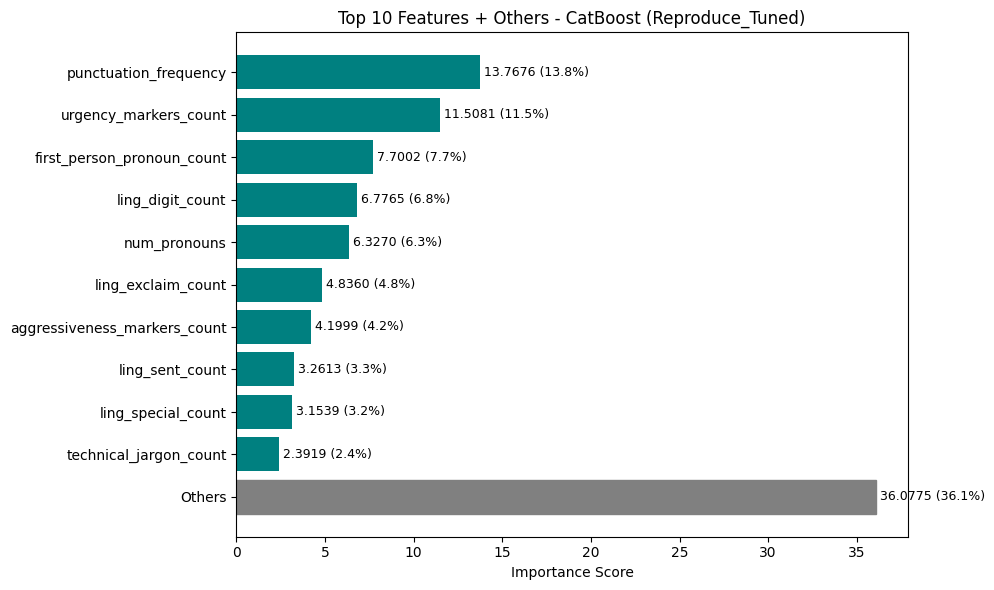



🧬 EXPERIMENT: Exp_A
📌 Type: New Idea (Behavioral) 💡
📝 Detail: Stylo + Advanced Features | With Tuning & Selection

[1/9] Tuning... LogisticRegression
   ✅ Best Params: {'C': 0.057012568613371555}
[2/9] Tuning... SVM
   ✅ Best Params: {'C': 0.0745934328572655}
[3/9] Tuning... RandomForest
   ✅ Best Params: {'n_est': 168, 'depth': 20}
[4/9] Tuning... XGBoost
   ✅ Best Params: {'n_est': 216, 'lr': 0.2890380020348278, 'depth': 3}
[5/9] Tuning... AdaBoost
   ✅ Best Params: {'n_est': 33, 'lr': 0.8706020878304853}
[6/9] Tuning... CatBoost
   ✅ Best Params: {'itr': 200, 'depth': 5, 'lr': 0.01699897838270077}
[7/9] Tuning... LightGBM
   ✅ Best Params: {'n_est': 230, 'lr': 0.04599892985526085, 'num_leaves': 93}
[8/9] Tuning... NaiveBayes
   ✅ Best Params: {'alpha': 0.13292918943162169}
[9/9] Tuning... DecisionTree
   ✅ Best Params: {'max_depth': 24, 'min_samples_split': 6, 'criterion': 'gini'}

📊 Exp_A - Training Set


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
SVM,0.9800,1.0000,0.9615,0.9804,0.9608,0.9992,0.9992
LogisticRegression,0.9700,0.9800,0.9608,0.9703,0.9402,0.9956,0.9956
NaiveBayes,0.8300,0.7600,0.8837,0.8172,0.6666,0.9452,0.9449



📊 Exp_A - Validation Set (CV Mean)


,F1-score,MCC-score,Accuracy,AUC,Precision,Recall
Model,,,,,,
LogisticRegression,0.9018,0.8051,0.9000,0.9420,0.8885,0.9200
LightGBM,0.8964,0.8080,0.9000,0.9740,0.9222,0.8800
SVM,0.8807,0.7842,0.8900,0.9580,0.9278,0.8400
RandomForest,0.8759,0.7701,0.8800,0.9650,0.8833,0.8800
XGBoost,0.8564,0.7480,0.8700,0.9740,0.8865,0.8400
AdaBoost,0.8517,0.7339,0.8600,0.9720,0.9022,0.8200
CatBoost,0.8489,0.7271,0.8600,0.9580,0.8695,0.8400
NaiveBayes,0.7994,0.6278,0.8100,0.9160,0.8511,0.7600
DecisionTree,0.7983,0.6317,0.8100,0.8090,0.7926,0.8200



📊 Exp_A - Test Set (Unseen Data)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,0.8846,0.8462,0.9167,0.8800,0.7715,0.9645,0.9633
CatBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9586,0.9577
SVM,0.8846,0.7692,1.0000,0.8696,0.7906,0.9172,0.9360
DecisionTree,0.8077,0.7692,0.8333,0.8000,0.6172,0.8077,0.7564
LightGBM,0.8077,0.7692,0.8333,0.8000,0.6172,0.9527,0.9541
AdaBoost,0.8077,0.6923,0.9000,0.7826,0.6325,0.9349,0.9335
XGBoost,0.8077,0.6923,0.9000,0.7826,0.6325,0.9467,0.9464
LogisticRegression,0.7692,0.6923,0.8182,0.7500,0.5449,0.8817,0.8634
NaiveBayes,0.6538,0.4615,0.7500,0.5714,0.3333,0.8580,0.8120



📊 Exp_A - Confusion Matrix (Test Set)


,TN,FP,FN,TP
Model,,,,
LogisticRegression,11,2,4,9
SVM,13,0,3,10
RandomForest,12,1,2,11
XGBoost,12,1,4,9
AdaBoost,12,1,4,9
CatBoost,12,1,2,11
LightGBM,11,2,3,10
NaiveBayes,11,2,7,6
DecisionTree,11,2,3,10


⭐ Best Model: RandomForest


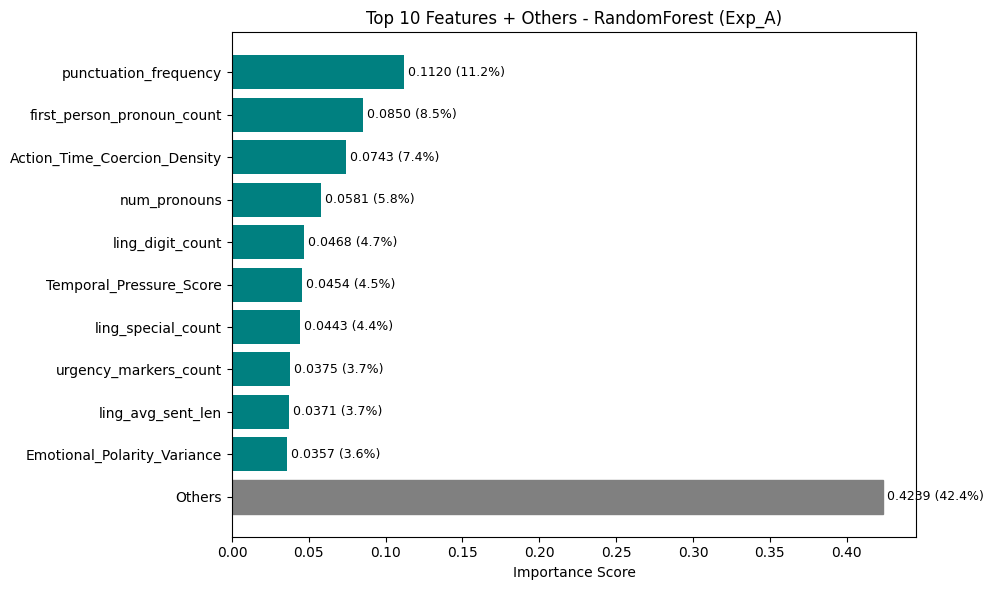



🧬 EXPERIMENT: Exp_B
📌 Type: New Idea (Content) 📝
📝 Detail: TF-IDF Only | With Tuning

[1/9] Tuning... LogisticRegression
   ✅ Best Params: {'C': 56.69849511478853}
[2/9] Tuning... SVM
   ✅ Best Params: {'C': 56.69849511478853}
[3/9] Tuning... RandomForest
   ✅ Best Params: {'n_est': 55, 'depth': 20}
[4/9] Tuning... XGBoost
   ✅ Best Params: {'n_est': 284, 'lr': 0.08820401042222294, 'depth': 6}
[5/9] Tuning... AdaBoost
   ✅ Best Params: {'n_est': 155, 'lr': 0.15751320499779725}
[6/9] Tuning... CatBoost
   ✅ Best Params: {'itr': 289, 'depth': 4, 'lr': 0.010260022325256584}
[7/9] Tuning... LightGBM
   ✅ Best Params: {'n_est': 227, 'lr': 0.010725209743171997, 'num_leaves': 98}
[8/9] Tuning... NaiveBayes
   ✅ Best Params: {'alpha': 0.014936568554617643}
[9/9] Tuning... DecisionTree
   ✅ Best Params: {'max_depth': 13, 'min_samples_split': 20, 'criterion': 'gini'}

📊 Exp_B - Training Set


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
NaiveBayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,0.9700,0.9800,0.9608,0.9703,0.9402,0.9992,0.9992



📊 Exp_B - Validation Set (CV Mean)


,F1-score,MCC-score,Accuracy,AUC,Precision,Recall
Model,,,,,,
LogisticRegression,0.9799,0.9618,0.9800,0.9980,0.9818,0.9800
SVM,0.9799,0.9618,0.9800,0.9980,0.9818,0.9800
NaiveBayes,0.9694,0.9427,0.9700,0.9960,0.9818,0.9600
RandomForest,0.9628,0.9251,0.9600,0.9850,0.9303,1.0000
AdaBoost,0.9523,0.9042,0.9500,0.9840,0.9285,0.9800
CatBoost,0.9523,0.9042,0.9500,0.9740,0.9285,0.9800
XGBoost,0.9159,0.8267,0.9100,0.9680,0.8785,0.9600
LightGBM,0.9096,0.8168,0.9000,0.9780,0.8544,0.9800
DecisionTree,0.8300,0.6669,0.8300,0.8510,0.8067,0.8600



📊 Exp_B - Test Set (Unseen Data)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LogisticRegression,0.9615,1.0000,0.9286,0.9630,0.9258,1.0000,1.0000
NaiveBayes,0.9231,1.0000,0.8667,0.9286,0.8563,0.9822,0.9822
AdaBoost,0.8846,0.9231,0.8571,0.8889,0.7715,0.9763,0.9774
RandomForest,0.8846,0.9231,0.8571,0.8889,0.7715,0.9763,0.9788
CatBoost,0.8462,0.8462,0.8462,0.8462,0.6923,0.9586,0.9577
DecisionTree,0.8462,0.7692,0.9091,0.8333,0.7006,0.8462,0.8147
LightGBM,0.7692,0.6923,0.8182,0.7500,0.5449,0.9231,0.9230
XGBoost,0.7308,0.6923,0.7500,0.7200,0.4629,0.8994,0.9029



📊 Exp_B - Confusion Matrix (Test Set)


,TN,FP,FN,TP
Model,,,,
LogisticRegression,12,1,0,13
SVM,13,0,0,13
RandomForest,11,2,1,12
XGBoost,10,3,4,9
AdaBoost,11,2,1,12
CatBoost,11,2,2,11
LightGBM,11,2,4,9
NaiveBayes,11,2,0,13
DecisionTree,12,1,3,10


⭐ Best Model: SVM


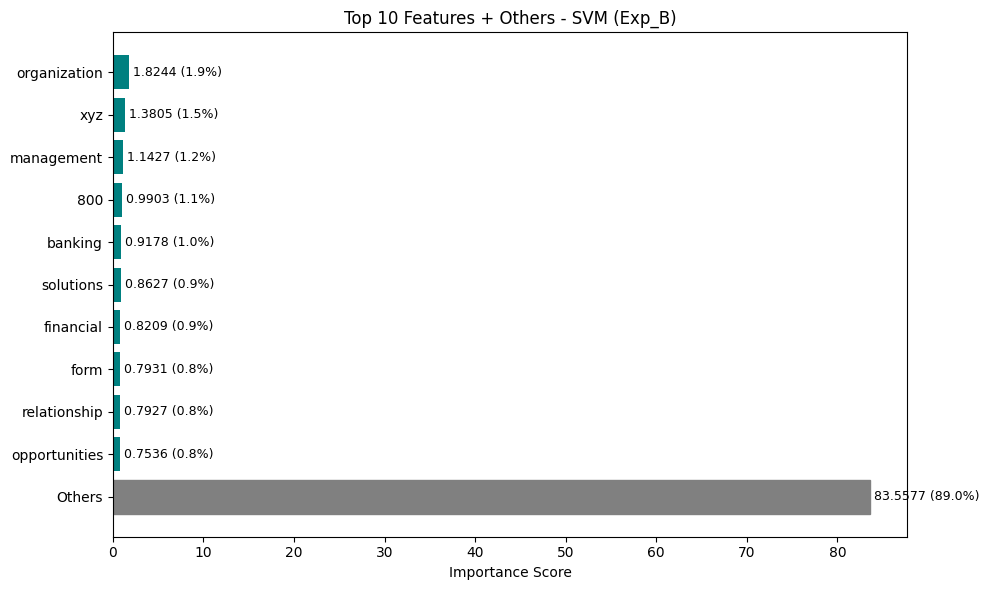



🧬 EXPERIMENT: Exp_C
📌 Type: New Idea (Hybrid) 🧬
📝 Detail: Combined All Features | With Tuning

[1/9] Tuning... LogisticRegression
   ✅ Best Params: {'C': 0.0745934328572655}
[2/9] Tuning... SVM
   ✅ Best Params: {'C': 0.0745934328572655}
[3/9] Tuning... RandomForest
   ✅ Best Params: {'n_est': 233, 'depth': 13}
[4/9] Tuning... XGBoost
   ✅ Best Params: {'n_est': 200, 'lr': 0.01700037298921102, 'depth': 4}
[5/9] Tuning... AdaBoost
   ✅ Best Params: {'n_est': 132, 'lr': 0.2607024758370766}
[6/9] Tuning... CatBoost
   ✅ Best Params: {'itr': 299, 'depth': 4, 'lr': 0.035536650055285154}
[7/9] Tuning... LightGBM
   ✅ Best Params: {'n_est': 185, 'lr': 0.10448448531784886, 'num_leaves': 20}
[8/9] Tuning... NaiveBayes
   ✅ Best Params: {'alpha': 0.02938027938703535}
[9/9] Tuning... DecisionTree
   ✅ Best Params: {'max_depth': 13, 'min_samples_split': 20, 'criterion': 'gini'}

📊 Exp_C - Training Set


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LogisticRegression,0.9800,1.0000,0.9615,0.9804,0.9608,0.9976,0.9976
SVM,0.9800,1.0000,0.9615,0.9804,0.9608,0.9996,0.9996
NaiveBayes,0.8500,0.8000,0.8889,0.8421,0.7035,0.9604,0.9599



📊 Exp_C - Validation Set (CV Mean)


,F1-score,MCC-score,Accuracy,AUC,Precision,Recall
Model,,,,,,
RandomForest,0.9610,0.9218,0.9600,0.9860,0.9436,0.9800
AdaBoost,0.9410,0.8818,0.9400,0.9820,0.9236,0.9600
LightGBM,0.9332,0.8660,0.9300,0.9780,0.8921,0.9800
CatBoost,0.9332,0.8660,0.9300,0.9820,0.8921,0.9800
LogisticRegression,0.9018,0.8051,0.9000,0.9480,0.8885,0.9200
XGBoost,0.8764,0.7508,0.8700,0.9440,0.8434,0.9200
SVM,0.8712,0.7633,0.8800,0.9560,0.9078,0.8400
NaiveBayes,0.8319,0.6887,0.8400,0.9380,0.8770,0.8000
DecisionTree,0.8152,0.6693,0.8300,0.8340,0.8091,0.8400



📊 Exp_C - Test Set (Unseen Data)


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Model,,,,,,,
RandomForest,0.9231,0.9231,0.9231,0.9231,0.8462,0.9763,0.9752
LightGBM,0.8846,0.8462,0.9167,0.8800,0.7715,0.9645,0.9589
AdaBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9763,0.9752
CatBoost,0.8846,0.8462,0.9167,0.8800,0.7715,0.9467,0.9395
SVM,0.8462,0.6923,1.0000,0.8182,0.7276,0.9112,0.9326
DecisionTree,0.8077,0.7692,0.8333,0.8000,0.6172,0.8077,0.7564
XGBoost,0.8077,0.7692,0.8333,0.8000,0.6172,0.9290,0.9241
LogisticRegression,0.7692,0.6923,0.8182,0.7500,0.5449,0.8817,0.8634
NaiveBayes,0.6923,0.5385,0.7778,0.6364,0.4042,0.8817,0.8295



📊 Exp_C - Confusion Matrix (Test Set)


,TN,FP,FN,TP
Model,,,,
LogisticRegression,11,2,4,9
SVM,13,0,4,9
RandomForest,12,1,1,12
XGBoost,11,2,3,10
AdaBoost,12,1,2,11
CatBoost,12,1,2,11
LightGBM,12,1,2,11
NaiveBayes,11,2,6,7
DecisionTree,11,2,3,10


⭐ Best Model: RandomForest


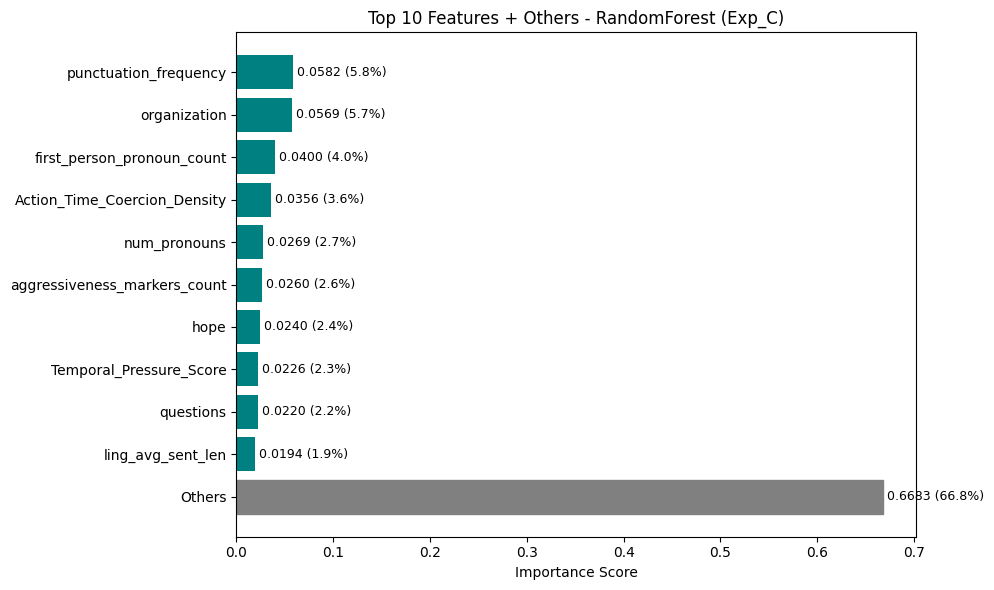



 Final Comparison 


,Experiment,Avg_F1,Best_Model,Best_F1
3,Exp_B,0.8688,SVM,1.0000
4,Exp_C,0.8186,RandomForest,0.9231
2,Exp_A,0.7907,RandomForest,0.8800
0,Reproduce_Untuned,0.7833,RandomForest,0.8333
1,Reproduce_Tuned,0.7616,CatBoost,0.8800



🏆 Winner: Exp_B with SVM

✨ Best Hyperparameters for Winner (SVM):
{'C': 56.69849511478853}

📈 Generating Cost Function Chart for SVM...


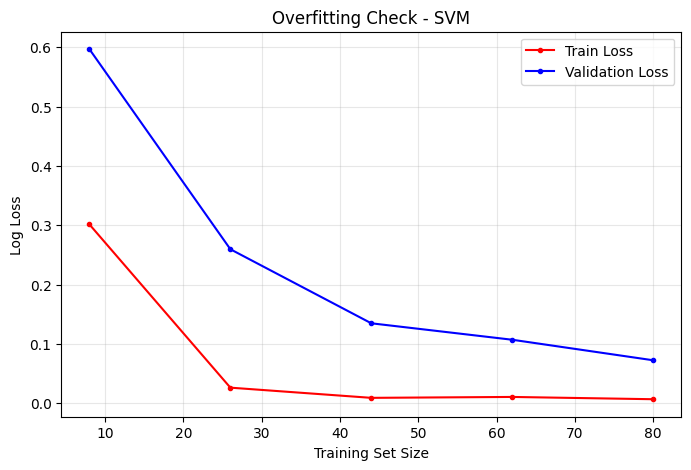


🔍 Top-K Feature Selection Analysis on SVM...


,Accuracy,Recall,Precision,F1-score,MCC-score,AUC,PR
Top-K,,,,,,,
10,0.8846,0.9231,0.8571,0.8889,0.7715,0.9408,0.9538
20,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
30,0.9615,1.0000,0.9286,0.9630,0.9258,1.0000,1.0000


In [73]:
# ==========================================================
# PART 4 : Main Execution
# ==========================================================
def main():
    results = {}
    all_best_params = {}

    # Run all 5 Experiments
    for key in experiments:
        df, models, data, params = run_experiment(key, experiments[key])
        results[key] = {"df": df, "models": models, "data": data}
        all_best_params[key] = params

    print(f"\n\n{'='*40}\n Final Comparison \n{'='*40}")
    summary = []
    for name, res in results.items():
        summary.append({
            "Experiment": name,
            "Avg_F1": res["df"]["F1-score"].mean(),
            "Best_Model": res["df"].index[0],
            "Best_F1": res["df"].iloc[0]["F1-score"]
        })

    df_sum = pd.DataFrame(summary).sort_values("Avg_F1", ascending=False)
    display(df_sum)

    # Select Best Global (from Tuned experiments mostly)
    # Exclude Untuned if needed, but here we just take the best Score
    best_exp = df_sum.iloc[0]["Experiment"]
    best_model_name = df_sum.iloc[0]["Best_Model"]

    print(f"\n🏆 Winner: {best_exp} with {best_model_name}")

    # Show Best Params for Winner
    print(f"\n✨ Best Hyperparameters for Winner ({best_model_name}):")
    print(all_best_params[best_exp][best_model_name])

    best_res = results[best_exp]
    best_model_obj = best_res["models"][best_model_name]

    plot_cost_function(best_model_obj, best_res["data"]["X_train"], y_train, best_res["data"]["X_test"], y_test, best_model_name)

    print(f"\n🔍 Top-K Feature Selection Analysis on {best_model_name}...")
    imp = None
    if hasattr(best_model_obj, "feature_importances_"): imp = best_model_obj.feature_importances_
    elif hasattr(best_model_obj, "coef_"): imp = np.abs(best_model_obj.coef_[0]) if best_model_obj.coef_.ndim > 1 else np.abs(best_model_obj.coef_)
    elif hasattr(best_model_obj, "feature_log_prob_"): imp = np.std(best_model_obj.feature_log_prob_, axis=0)

    if imp is not None:
        sorted_idx = np.argsort(imp)[::-1]
        fs_res = []
        for k in [10, 20, 30]:
            if k > len(imp): k = len(imp)
            idx = sorted_idx[:k]
            X_tr_k = best_res["data"]["X_train"][:, idx]
            X_te_k = best_res["data"]["X_test"][:, idx]
            m = clone(best_model_obj)
            m.fit(X_tr_k, y_train)
            y_p = m.predict(X_te_k)
            y_pb = m.predict_proba(X_te_k)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X_te_k)
            fs_res.append({"Top-K": k, **calculate_metrics(y_test, y_p, y_pb)})
        display(pd.DataFrame(fs_res).set_index("Top-K"))
    else:
        print("Feature selection not supported for this model structure.")

if __name__ == "__main__":
    main()